In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("playground-series-s6e4/train.csv")

In [3]:
data.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [4]:
data.isnull().sum()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [5]:
data.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

# Exploratory Data Analysis

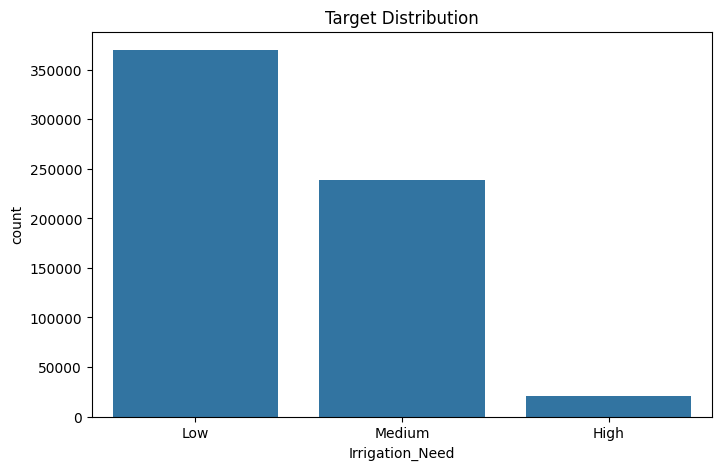

In [7]:
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(8,5))
sns.countplot(data=data, x='Irrigation_Need')
plt.title('Target Distribution')
plt.show()

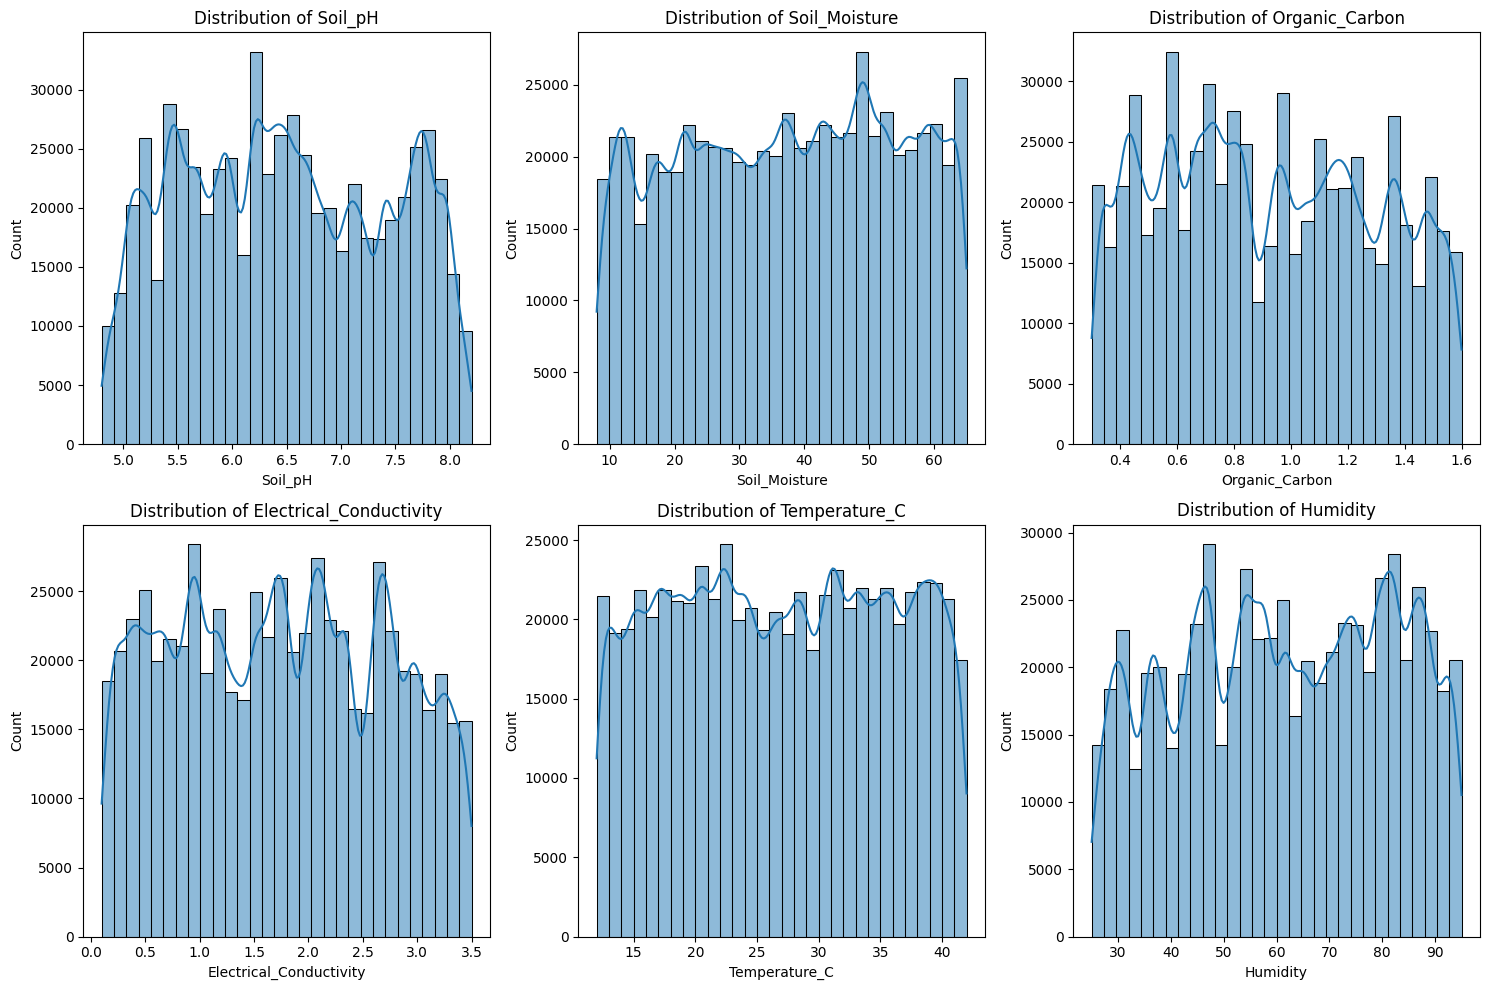

In [8]:
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns.drop('id')
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols[:6]):
    plt.subplot(2, 3, i+1)
    sns.histplot(data[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

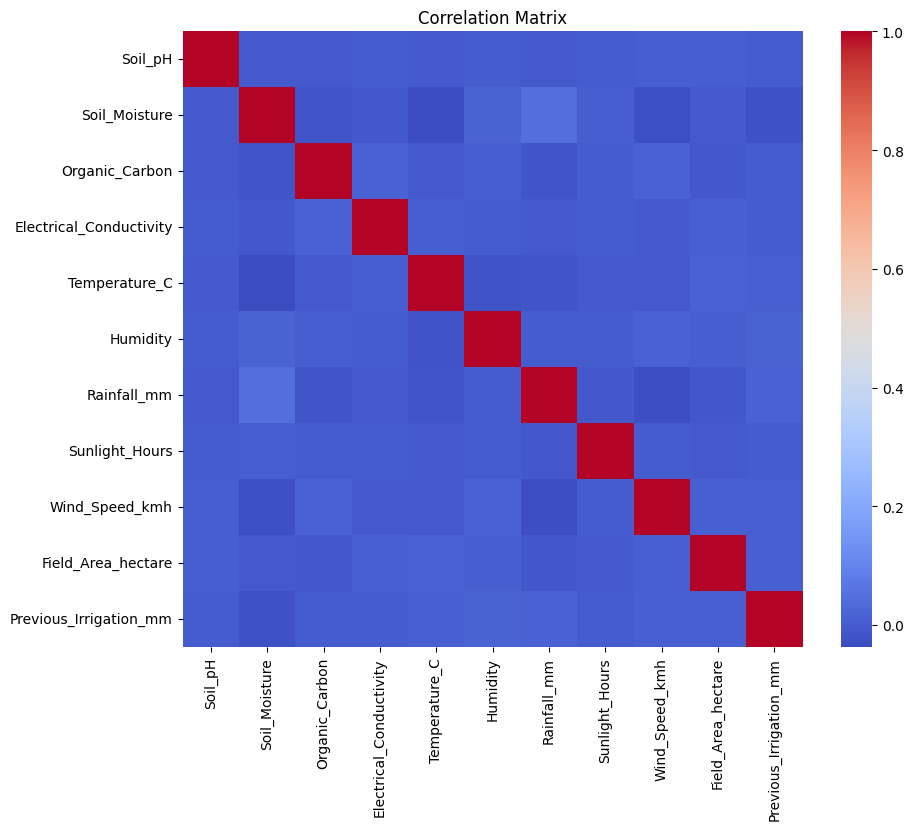

In [9]:
plt.figure(figsize=(10,8))
corr = data[numeric_cols].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Data Preprocessing

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# We downsample the data for faster training, but you can use the full dataframe if desired
df_sampled = data.sample(n=100000, random_state=42)

X = df_sampled.drop(['id', 'Irrigation_Need'], axis=1)
y = df_sampled['Irrigation_Need']

# Encoding categorical columns
cat_cols = X.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

le_target = LabelEncoder()
y = le_target.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training and Evaluation

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

best_model = None
best_accuracy = 0
best_name = ""

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}\n")
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_name = name

print(f"Best Model: {best_name} with Accuracy: {best_accuracy:.4f}")

Training Logistic Regression...
Logistic Regression Accuracy: 0.7478

Training Decision Tree...
Decision Tree Accuracy: 0.9691

Training Random Forest...
Random Forest Accuracy: 0.9848

Training XGBoost...
XGBoost Accuracy: 0.9844

Best Model: Random Forest with Accuracy: 0.9848


In [14]:
# Saving the best model and scaler
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_target, 'target_encoder.pkl')
print(f"Saved {best_name} as best_model.pkl")

Saved Random Forest as best_model.pkl


# Make Predictions on Test Data

In [15]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder

print("Loading test data...")
test_data = pd.read_csv("playground-series-s6e4/test.csv")

# Extract id for submission
test_ids = test_data['id']
X_test_sub = test_data.drop('id', axis=1)

# Ensure categorical encoding aligns
# For robust preprocessing, one would typically load fitted Encoders from training,
# but we will encode here dynamically mimicking our training procedure.
cat_cols = X_test_sub.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    # Fit and transform to categorical numerically
    X_test_sub[col] = le.fit_transform(X_test_sub[col].astype(str))

# Load saved scaler and scale numeric features
scaler = joblib.load('scaler.pkl')
X_test_sub_scaled = scaler.transform(X_test_sub)

# Load the best model and target encoder
best_model = joblib.load('best_model.pkl')
le_target = joblib.load('target_encoder.pkl')

print("Generating predictions with the best algorithm...")
y_pred_sub = best_model.predict(X_test_sub_scaled)

# Inverse transform numeric targets back to original labels (Low, Medium, High)
y_pred_original = le_target.inverse_transform(y_pred_sub)

# Create submission dataframe
submission = pd.DataFrame({
    'id': test_ids,
    'Irrigation_Need': y_pred_original
})

# Save to CSV
submission_path = "submission.csv"
submission.to_csv(submission_path, index=False)
print(f"Predictions successfully saved to {submission_path}")

# Preview the output
submission.head()

Loading test data...
Generating predictions with the best algorithm...
Predictions successfully saved to submission.csv


,id,Irrigation_Need
0,630000,Low
1,630001,Low
2,630002,Low
3,630003,Low
4,630004,Low
